# Regression



머신 러닝(Machine Learning) 종류 - 사람의 감독 하에 훈련하는 것인 지 여부
* 지도 학습(Supervised learning): 레이블(타겟)이 있는 데이터를 학습.
  * 분류(Classification): 클래스들을 분류.
  * 회기(Regression): 수치 예측.
* 비지도 학습(Unsupervised learning): 레이블이 없는 데이터를 학습.
  * 군집화(Clustering)
  * 시각화(Visualization)
* 준지도 학습(semi-supervised learning): 비지도 학습 + 전문가 시스템.  

# 문제

fish 데이터셋에서 물고기의 무게(Weight)를 예측.
* 농어(Perch)의 무게(Weight)를 길이(Length) 특성만으로 예측.
  * Weight ~ Length
  * 무게(Weight): 관심 변수, 종속 변수, 레이블, 타겟.
  * 길이(Length): 독립 변수, 특성(feature).
  * KNN, Linear Regression(선형 회귀)
* 농어의 무게를 다른 4개의 특성들을 사용해서 예측.   
  * Weight ~ Length + Diagonal + Height + Width
  * Linear Regression

# Imports

In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # 표준화(특성 스케일링)
from sklearn.preprocessing import PolynomialFeatures # 다차항을 추가할 수 있는 변환기
from sklearn.neighbors import KNeighborsRegressor # KNN 알고리즘을 사용한 회귀.

from sklearn.linear_model import LinearRegression # 선형 회귀
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # 회귀 평가 지표
from sklearn.pipeline import Pipeline# 교제에없다 // 변환기와 추정기를 연결하는 클래스.

# Fish 데이터셋 준비

In [173]:
fish_path='https://bit.ly/fish_csv_data'

In [174]:
fish=pd.read_csv(fish_path)
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [175]:
perch=fish[fish.Species=='Perch']

In [176]:
perch[:5]

,Species,Weight,Length,Diagonal,Height,Width
72,Perch,5.9,8.4,8.8,2.1120,1.4080
73,Perch,32.0,13.7,14.7,3.5280,1.9992
74,Perch,40.0,15.0,16.0,3.8240,2.4320
75,Perch,51.5,16.2,17.2,4.5924,2.6316
76,Perch,70.0,17.4,18.5,4.5880,2.9415


In [177]:
perch.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 72 to 127
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   56 non-null     object 
 1   Weight    56 non-null     float64
 2   Length    56 non-null     float64
 3   Diagonal  56 non-null     float64
 4   Height    56 non-null     float64
 5   Width     56 non-null     float64
dtypes: float64(5), object(1)
memory usage: 3.1+ KB


In [178]:
# 특성 배열(features array)
x= perch[['Length']].values
x.shape # 값 하나를 2차원 배열로 (56,1) = (n_samples, n_features)

(56, 1)

In [179]:
# 타겟 배열(target array)
y=perch['Weight'].values
y.shape # (56,) = (n_samples,)

(56,)

농어(Perch)의 무게(Weight)를 길이(Length)만으로 예측할 수 있을까?

* 특성(feature): Length --> (n_sample, n_features) **2차원 배열**
* 타겟(target): Weight --> (n_samples,) 모양의 **1차원 배열**


# 훈련 셋, 테스트 셋 분리

In [180]:
# perch[['Length']].values.copy()
# 분류를할필요없다 (층화)
# shuffle만
# 어종이 여러개면 분류과정 필요

# 임의추출 이용 shuffle은 기본값
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [181]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((42, 1), (14, 1), (42,), (14,))

In [182]:
X_train[:5]

array([[19.6],
       [22. ],
       [18.7],
       [17.4],
       [36. ]])

In [183]:
y_train[:5]

array([ 85., 135.,  78.,  70., 700.])

훈련 셋, 테스트 셋 시각화: weight(y) ~ length(x) 산점도. 색깔(훈련/테스트)

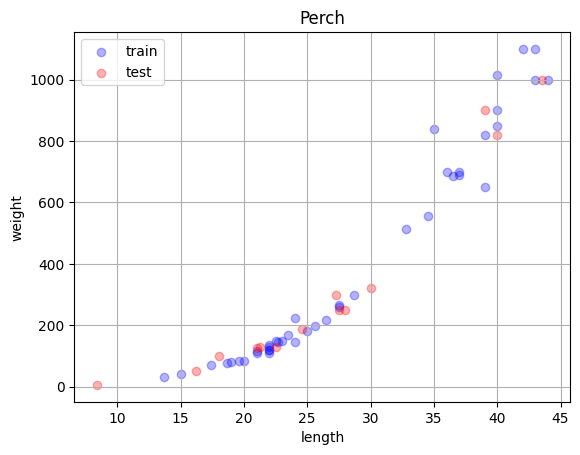

In [184]:
plt.scatter(x=X_train,y=y_train,color='blue',alpha=0.3,label='train')
plt.scatter(x=X_test,y=y_test,color='red',alpha=0.3,label='test')
plt.legend()
plt.xlabel('length')
plt.ylabel('weight')
plt.title('Perch')
plt.grid()
plt.show()

# KNN 모델 훈련, 평가

KNN(K-Nearest Neighbors) Regressor: k개의 가장 가까운 이웃들의 레이블 평균 값으로 수치를 예측하는 머신 러닝 모델.

In [185]:
knn = KNeighborsRegressor() # KNN 모델 생성


In [186]:
knn.fit(X=X_train,y=y_train) # KNN 모델 훈련

KNeighborsRegressor()

In [187]:
train_pred=knn.predict(X=X_train) # 훈련 셋의 예측값

In [188]:
train_pred#길이

array([  88.6,  123. ,   79.6,   70.6,  723. ,  193. ,  847. ,  847. ,
       1010. ,  123. ,   95. ,  123. ,  174. ,  248. , 1010. ,  847. ,
        174. ,  113. ,  248. ,  847. ,  659. ,  224. ,  723. ,   60. ,
        140. ,   60. ,  719. ,  694.2,  248. ,  167. ,  847. ,  113. ,
        168. ,  123. , 1010. ,  136. ,   79.6,  719. ,  123. ,  193. ,
        990. ,  659. ])

In [189]:
y_train # 훈련 셋 실젯값

array([  85.,  135.,   78.,   70.,  700.,  180.,  850.,  820., 1000.,
        120.,   85.,  130.,  225.,  260., 1100.,  900.,  145.,  115.,
        265., 1015.,  514.,  218.,  685.,   32.,  145.,   40.,  690.,
        840.,  300.,  170.,  650.,  110.,  150.,  110., 1000.,  150.,
         80.,  700.,  120.,  197., 1100.,  556.])

In [190]:
test_pred=knn.predict(X=X_test) # 테스트 셋의 예측값
test_pred

array([  60. ,   79.6,  248. ,  122. ,  136. ,  847. ,  311.4,  183.4,
        847. ,  113. , 1010. ,   60. ,  248. ,  248. ])

In [191]:
y_test

array([   5.9,  100. ,  250. ,  130. ,  130. ,  820. ,  320. ,  188. ,
        900. ,  125. , 1000. ,   51.5,  250. ,  300. ])

# 희귀 모델의 평가 지표(metrics)

* MSE(Mean Squared Errors): 오차들의 제곱의 평균.
* RMSE(Root Mean Squared Errors): MSE의 제곱근.
* MAE(Mean Absolute Errors): 오차들의 절댓값의 평균.
* MAW,RMSE,MAE는 값이 작을 수록 좋은 점수, 값이 클 수록 나쁜 점수!
  * 일반적으로 점수(평가지표)는 값이 클 수록 좋은 점수, 값이 작을 수록 나쁜 점수.
  * 회귀 문제에서도 오차들이 작을 수록 점수가 커지는 평가지표를 개발 -> R2 score(결정 계수)
* R2(R^2) score(결정계수): -무한대(infinite) ~ 1 사이의 값을 가질 수 있음.
  * 모든 수치를 오차없이 **정확**하게 예측한 경우 최댓값 1.  
  * 오차들이 클 수록 결정계수는 작아짐.
* $ y_i $ : $i$번째 샘플의 실젯값(label)
* $ \hat{y_i} $ : $i$번째 샘플의 예측값
* $ \bar{y} $ : 타겟의 평균값
* $ n $ : 샘플 개수

* MAE(Mean Absolute Errors)
$$
MAE = \frac{1}{n} \sum_{i=1}^{n} \lvert y_i - \hat{y_i} \rvert
$$

* MSE(Mean Squared Errors)
$$
MSE = \frac{1}{n} \sum_{i=1}^{n} ( y_i - \hat{y_i} )^2
$$

* RMSE(Root Mean Squared Errors)
$$
RMSE = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} ( y_i - \hat{y_i} )^2 }
$$

* $ R^2 $ score(Coefficient of determinant, 결정 계수)
$$
R^2 = 1 - \dfrac{\text{MSE}}{\text{Variance}}
    = 1 - \dfrac{ \sum_{i=1}^{n} (y_i - \hat{y_i})^2 }
                { \sum_{i=1}^{n} (y_i - \bar{y})^2 }
$$
    * 결정 계수는 최댓값이 1이 되도록 만든 평가 지표.
    * 모델이 타겟을 오차없이 정확하게 예측하면, 실제값 - 예측값 = 0 이므로, 결정 계수는 최댓값 1이 됨.
    * 모델이 타겟을 매우 비슷하게 예측하면, 오차가 매우 작으면 분자가 0에 가까운 값이 되므로, 결정 계수는 1보다는 작지만 1에 가까운 값이 됨.
    * 모델이 타겟의 평균으로만 예측하는 정도라면, (분자) = (분모) 이므로, 결정 계수는 0이 됨.
    * 모델이 타겟의 평균 정도도 예측하지 못하면(오차가 매우 크면), (분자) > (분모)일 수 있고, 그런 경우 결정 계수는 음수가 될 수 있음.


In [192]:
# 예측 - y 의 평균값(제곱,절댓값)
# 훈련 셋의 MSE
mean_squared_error(y_true=y_train,y_pred=train_pred)

3716.5161904761903

In [193]:
# 훈련 셋의 RMSE
np.sqrt(mean_squared_error(y_train,train_pred))

np.float64(60.96323638453089)

In [194]:
# root_mean_squared_error=np.sqrt(mean_squared_error(y_train,train_pred))

In [195]:
# 훈련 셋의 MAE
mean_absolute_error(y_true=y_train,y_pred=train_pred)

35.76190476190476

In [196]:
# 훈련 셋의 결정계수(R2 score)
r2_score(y_true=y_train,y_pred=train_pred)

0.9698823289099254

In [197]:
# 훈련된 KNN 모델에서 score 메서드를 호출 >> 결정계수 리턴
# knn.score 정확도
knn.score(X=X_train,y=y_train) # r2 score

0.9698823289099254

In [198]:
# KNN 모델에서 score 메서드를 호출해서 테스트 셋의 결정계수 계산
knn.score(X=X_test,y=y_test) # 훈련 셋의 평가점수보다 테스트 셋의 평가점수가 더 좋으면 과소적합, 그반대 과적합
# 셈플 수가적으면 과소적합이 잘 나타난다(under-fitting)

0.992809406101064

In [199]:
# 테스트 셋의 MAE  작으면 좋다
mean_absolute_error(y_true=y_test,y_pred=test_pred)

19.157142857142862

In [200]:
# 테스트 셋의 MSE 작으면 좋다
mean_squared_error(y_true=y_test,y_pred=test_pred)


721.7385714285714

# KNN Regressor 문제점

outlier가 있는 경우 오차가 커질 수 있다.

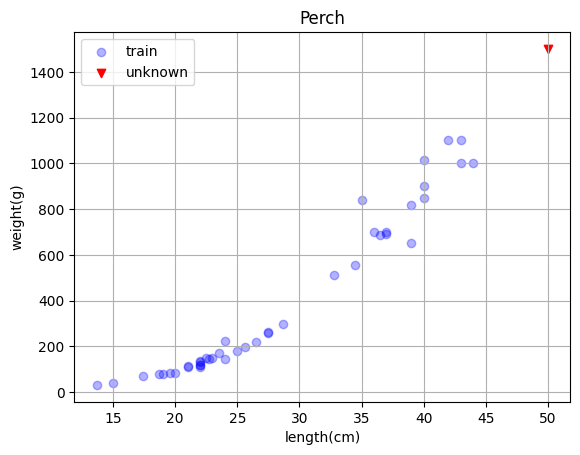

In [201]:
# 훈련 셋 시각화
plt.scatter(x=X_train,y=y_train,label='train',alpha=0.3,color='Blue')

# 가상의 물고기( 50, 1500)
plt.scatter(x=50,y=1500,label='unknown',color='red',marker='v')

plt.legend()
plt.xlabel('length(cm)')
plt.ylabel('weight(g)')
plt.title('Perch')
plt.grid()
plt.show()

# 길이가 50cm인 물고기 무게 예측


In [202]:
# 길이가 50cm인 물고기와 가장 가까운 5개의 훈련 셋 샘플들
d,i=knn.kneighbors(X=[[50]],n_neighbors=5)
print(d)
print(i)

[[ 6.  7.  7.  8. 10.]]
[[34 14  8 40  6]]


In [203]:
# 5개의 가장 가까운 이웃들의 무게
y_train[i[0]] # x 는 무게 y 는 길이

array([1000., 1100., 1000., 1100.,  850.])

In [204]:
# 가장 가까운 이웃들의 무게 평균
np.mean(y_train[i[0]])

np.float64(1010.0)

In [205]:
knn.predict(X=[[50]]) # 거리계산 평균계산

array([1010.])

머신 러닝의 종류 - 단순하게(KNN) 알고 있는 데이터 포인트와 새 데이터 포인트를 비교하는 것인지, 아니면 훈련 셋에서 패턴을 발견(수학적인 공식을 발견)해서 예측 모델을 만드는지
* 지도학습중에
* 사례 기반 머신 러닝(instance-based ML)
   * 수학적인 모델을 만들 지 않고, 훈련 셋의 특성들을 사용해서 예측.
   * outlier들이 많은 경우에는 성능이 안좋아질 수 있음.
   * KNN, Decision Tree, ...
* 모델 기반 머신 러닝(model-based ML)
   * 훈련 셋의 특성들에서 수학적인 모델을 만들고, 그 수학 모델로 예측.
   * Linear Regression(선형 회귀), Logistic Regression(로지스틱 회귀), ...
   *       회귀 - 선형 회귀         분류 - 로지스틱 회귀

# Linear Regression(선형 회귀)

In [206]:
# y절편=인터셉트 기울기=코이피션트 coef_
lin_reg=LinearRegression() # 선형 회귀 모델 생성

In [207]:
lin_reg.fit(X=X_train,y=y_train) # 선형 회귀 모델 훈련
# MSE가 최소가 되는 선형 회귀식의 계수(들)과 절편(들)을 찾는 과정

LinearRegression()

In [208]:
lin_reg.coef_ # x의 기울기(계수 y=ax+b에서 a)

array([39.01714496])

In [209]:
lin_reg.intercept_ # y절편( y=ax+b에서 b)

np.float64(-709.0186449535477)

$ y = 39 x (-709) $ 선형 회귀 모델에서 찾은 선형회귀식

In [210]:
train_pred=lin_reg.predict(X=X_train) # 길이 훈련
# 선형회귀에서 훈련 셋의 예측값

In [211]:
train_pred

array([  55.71739633,  149.35854425,   20.60196587,  -30.12032259,
        695.59857374,  266.40997914,  851.66715359,  812.65000863,
        968.71858848,  149.35854425,   71.32425432,  149.35854425,
        227.39283417,  363.95284155,  968.71858848,  851.66715359,
        227.39283417,  110.34139928,  363.95284155,  851.66715359,
        570.74370985,  324.93569658,  715.10714622, -174.48375895,
        176.67054572, -123.7614705 ,  734.6157187 ,  656.58142877,
        410.7734155 ,  207.88426169,  812.65000863,  110.34139928,
        188.37568921,  149.35854425, 1007.73573345,  168.86711673,
         32.30710936,  734.6157187 ,  149.35854425,  289.82026612,
        929.70144352,  637.07285629])

In [212]:
y_train

array([  85.,  135.,   78.,   70.,  700.,  180.,  850.,  820., 1000.,
        120.,   85.,  130.,  225.,  260., 1100.,  900.,  145.,  115.,
        265., 1015.,  514.,  218.,  685.,   32.,  145.,   40.,  690.,
        840.,  300.,  170.,  650.,  110.,  150.,  110., 1000.,  150.,
         80.,  700.,  120.,  197., 1100.,  556.])

In [213]:
# 훈련 셋의 MSE
mean_squared_error(y_true=y_train,y_pred=train_pred)

7422.953552609781

In [214]:
# 훈련 셋의 결정계수
r2_score(y_true=y_train,y_pred=train_pred)

0.939846333997604

In [215]:
# 테스트 셋의 예측값
tepred=lin_reg.predict(X=X_test)

In [216]:
# 테스트 셋의 MSE
mean_squared_error(y_true=y_test,y_pred=tepred)
#

17590.265977889187

In [217]:
r2_score(y_true=y_test,y_pred=tepred)


0.8247503123313558

훈련 셋의 점수(0.94)가 테스트셋의 점수(0.82)보다 훨씬 좋음 >> 과대적합(over-fitting)

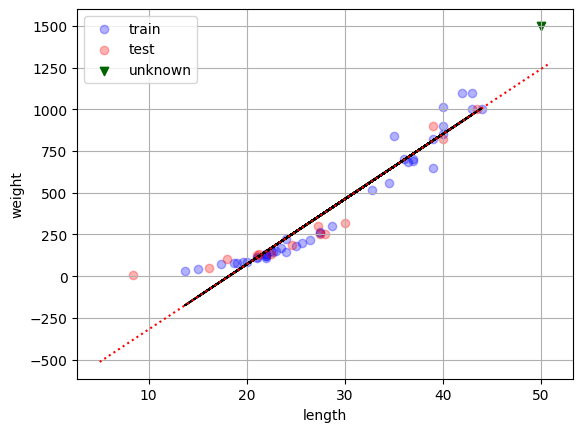

In [218]:
# 훈련 셋 산점도
# 테스트 셋 산점도
# y=39x-709 일차함수(직선) 시각화
plt.scatter(x=X_train,y=y_train,alpha=0.3,color='blue',label='train')
plt.scatter(x=X_test,y=y_test,alpha=0.3,color='red',label='test')
plt.plot(X_train,lin_reg.predict(X=X_train),color='black')
x_val=np.arange(5,51,0.0001)
y_val=39 * x_val -709
plt.plot(x_val,y_val,'r:')
# 가상의 물고기(50,1500) 시각화
plt.scatter(x=50,y=1500,color='DarkGreen',marker='v',label='unknown')

plt.legend()
plt.xlabel('length')
plt.ylabel('weight')
plt.grid()
plt.show()

# 다항 회귀

2개이상의 변수(특성)을 사용한 선형 회귀.

2차항 이상을 포함하는 선형 회귀.

In [219]:
X_train.shape #(42,1)

(42, 1)

In [220]:
# 2차항을 추가한 훈련 셋 2차원 배열
x_train_poly=np.c_[X_train**2,X_train]

In [221]:
x_train_poly[:6]

array([[ 384.16,   19.6 ],
       [ 484.  ,   22.  ],
       [ 349.69,   18.7 ],
       [ 302.76,   17.4 ],
       [1296.  ,   36.  ],
       [ 625.  ,   25.  ]])

In [222]:
x_train_poly.shape #(42,2)

(42, 2)

In [223]:
# 2차항을 추가한 테스트 셋 2차원 배열
x_test_poly=np.c_[X_test**2,X_test]

In [224]:
x_test_poly[:6]

array([[  70.56,    8.4 ],
       [ 324.  ,   18.  ],
       [ 756.25,   27.5 ],
       [ 453.69,   21.3 ],
       [ 506.25,   22.5 ],
       [1600.  ,   40.  ]])

In [225]:
x_test_poly.shape #(14,2)

(14, 2)

In [226]:
lin_reg=LinearRegression() # 선형회귀 모델 생성

In [227]:
# 2차항(길이의 제곱)을 포함하는 훈련 셋으로 모델을 훈련 >> 계수(coefficients)와 절편(intercept)을 찾음.
lin_reg.fit(X=x_train_poly,y=y_train)

LinearRegression()

In [228]:
# 코이피션트 인터셉트 찾기
lin_reg.coef_ # x가 두개라서
# y=ax^2+bx+c 회귀식에서 계수 a와 b의 의미

array([  1.01433211, -21.55792498])

$ y = ax^2 + bx + c $ 회귀식에서 계수 a와 b를 의미.

In [229]:
lin_reg.intercept_ # c =116.05
#

np.float64(116.0502107827827)

$ y = ax^2 + bx + c $ 회귀식에서 절편 c를 의미한다. 1 + -21 + 116

In [230]:
# 훈련 셋 예측값
tre_pred=lin_reg.predict(X=x_train_poly)

In [231]:
tre_pred

array([  83.18070434,  132.71260219,   67.61880901,   48.04150559,
        654.5393253 ,  211.05965467,  876.66458663,  818.09027497,
       1064.55950693,  132.71260219,   90.62455496,  132.71260219,
        182.91530629,  290.29593158, 1064.55950693,  876.66458663,
        182.91530629,  110.65424646,  290.29593158,  876.66458663,
        500.20932803,  257.07992265,  680.52990177,   11.08663218,
        149.3605064 ,   20.90606071,  707.0276443 ,  604.07967051,
        332.83297906,  169.60388118,  818.09027497,  110.65424646,
        156.79962213,  132.71260219, 1131.24847547,  144.50252913,
         72.62352767,  707.0276443 ,  132.71260219,  228.92002253,
        999.89920261,  579.6105922 ])

In [232]:
y_train

array([  85.,  135.,   78.,   70.,  700.,  180.,  850.,  820., 1000.,
        120.,   85.,  130.,  225.,  260., 1100.,  900.,  145.,  115.,
        265., 1015.,  514.,  218.,  685.,   32.,  145.,   40.,  690.,
        840.,  300.,  170.,  650.,  110.,  150.,  110., 1000.,  150.,
         80.,  700.,  120.,  197., 1100.,  556.])

In [233]:
# 훈련 셋 결정계쑤
r2_score(y_true=y_train,y_pred=tre_pred)

0.9706807451768623

In [234]:
# 테스트 셋 예측값
testpred=lin_reg.predict(X=x_test_poly)

In [235]:
testpred

array([   6.5349146 ,   56.6511646 ,  290.29593158,  117.05874344,
        144.50252913,  876.66458663,  382.21135986,  199.55847561,
        818.09027497,  110.65424646, 1097.65040817,   33.01314491,
        307.66468513,  283.49043666])

In [236]:
y_test

array([   5.9,  100. ,  250. ,  130. ,  130. ,  820. ,  320. ,  188. ,
        900. ,  125. , 1000. ,   51.5,  250. ,  300. ])

In [237]:
# 테스트 셋 결정계수
r2_score(y_true=y_test,y_pred=testpred)

0.9775935108325122

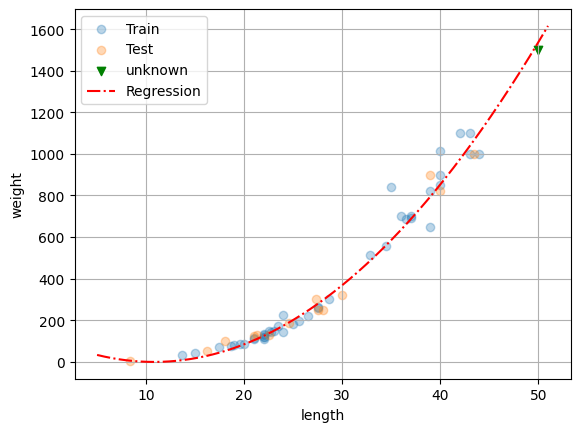

In [238]:
# 훈련 셋 산점도
plt.scatter(x=X_train,y=y_train,alpha=0.3,label='Train')

# 테스트 셋 산점도
plt.scatter(x=X_test,y=y_test,alpha=0.3,label='Test')

# 가상의 물고기 (50,1500)
plt.scatter(x=50,y=1500,label='unknown',color='green',marker='v')

# 2차 회귀식(2차 함수) 시각화 y=1 *x^2 + -21.6*x +116.1
x_val=np.arange(5,51,0.001)
y_val=1.0*x_val**2-21.6*x_val+116.1
plt.plot(x_val,y_val,'r-.',label='Regression')
# plt.plot(X_train,lin_reg.predict(X=x_train_poly),'o:') #1직선에서사용

plt.xlabel('length')
plt.ylabel('weight')
plt.grid()
plt.legend()
plt.show()

In [239]:
# 50cm 가상의 물고기의 무게
lin_reg.predict(X=[[50**2,50]]) # 1차항 2차항 각각 줘야한다

array([1573.98423528])

# numpy를 사용한 행렬 곱(matrix multipulication) 연산

* `@` 연산자
* `np.matmul()` 함수

## 1차원 배열의 행렬 곱

In [240]:
a=np.array([1,2,3]) #(3,) shape
b=np.array([4,5,6]) #(3,) shape

In [241]:
a @ b

np.int64(32)

In [242]:
np.matmul(a,b)

np.int64(32)

## 2차원 배열의 행렬 곱

`(i, j) @ (j, k) = (i, k)` shape

In [243]:
a=np.arange(1,7).reshape((2,3))
a

array([[1, 2, 3],
       [4, 5, 6]])

In [244]:
b=np.ones(shape=(3,2))
b

array([[1., 1.],
       [1., 1.],
       [1., 1.]])

In [245]:
a@b

array([[ 6.,  6.],
       [15., 15.]])

In [246]:
np.matmul(a,b)

array([[ 6.,  6.],
       [15., 15.]])

In [247]:
b@a

array([[5., 7., 9.],
       [5., 7., 9.],
       [5., 7., 9.]])

행렬 곱셈에서는 교환 법칙이 성립하지 않음. `a @ b != b @ a` 성립하지 않는다.

In [248]:
a=np.arange(1,13).reshape((3,4))
a

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [249]:
b=np.arange(0,12).reshape((4,3))
b

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11]])

In [250]:
# a @ b: (3,4) @ (4,3) > (3,3)
a @ b

array([[ 60,  70,  80],
       [132, 158, 184],
       [204, 246, 288]])

In [251]:
# b @ a: (4, 3) @ (3, 4) > (4,4)
b @ a

array([[ 23,  26,  29,  32],
       [ 68,  80,  92, 104],
       [113, 134, 155, 176],
       [158, 188, 218, 248]])

## 2차원 배열과 1차원 배열에서의 행렬 곱

* `(i, j) @ (j, ) = (i, )` shape: 2d array @ 1d array = 1d array
* `(i, j) @ (j, 1) = (i, 1)` shape: 2d array @ 2d array = 2d array

In [252]:
a= np.arange(1,7).reshape((2,3))
a

array([[1, 2, 3],
       [4, 5, 6]])

In [253]:
b=np.arange(1,4).reshape((3,))
b

array([1, 2, 3])

In [254]:
a@ b # (2,3) @ (3, ) = (2, ) 1d array

array([14, 32])

In [255]:
b=b.reshape((3,1))
b # (3,1)

array([[1],
       [2],
       [3]])

In [256]:
# (2,3) @ (3,1) =(2,1)
a @ b #(2,1) 2d array

array([[14],
       [32]])

## 선형 회귀에서의 행렬 곱 응용


In [257]:
x_train_poly.shape

(42, 2)

In [258]:
coef = lin_reg.coef_
coef.shape

(2,)

In [259]:
intercept = lin_reg.intercept_
intercept

np.float64(116.0502107827827)

In [260]:
x_train_poly @ coef+intercept # (42, 2) @ (2, ) = (42, )  x*a+b 물고기무게예측값

array([  83.18070434,  132.71260219,   67.61880901,   48.04150559,
        654.5393253 ,  211.05965467,  876.66458663,  818.09027497,
       1064.55950693,  132.71260219,   90.62455496,  132.71260219,
        182.91530629,  290.29593158, 1064.55950693,  876.66458663,
        182.91530629,  110.65424646,  290.29593158,  876.66458663,
        500.20932803,  257.07992265,  680.52990177,   11.08663218,
        149.3605064 ,   20.90606071,  707.0276443 ,  604.07967051,
        332.83297906,  169.60388118,  818.09027497,  110.65424646,
        156.79962213,  132.71260219, 1131.24847547,  144.50252913,
         72.62352767,  707.0276443 ,  132.71260219,  228.92002253,
        999.89920261,  579.6105922 ])

In [261]:
tre_pred

array([  83.18070434,  132.71260219,   67.61880901,   48.04150559,
        654.5393253 ,  211.05965467,  876.66458663,  818.09027497,
       1064.55950693,  132.71260219,   90.62455496,  132.71260219,
        182.91530629,  290.29593158, 1064.55950693,  876.66458663,
        182.91530629,  110.65424646,  290.29593158,  876.66458663,
        500.20932803,  257.07992265,  680.52990177,   11.08663218,
        149.3605064 ,   20.90606071,  707.0276443 ,  604.07967051,
        332.83297906,  169.60388118,  818.09027497,  110.65424646,
        156.79962213,  132.71260219, 1131.24847547,  144.50252913,
         72.62352767,  707.0276443 ,  132.71260219,  228.92002253,
        999.89920261,  579.6105922 ])

# Pipeline

변환기와 추정기(예측기)를 연결해 주는 클래스.

scikit - learn 패키지의 클래스:
* 변환기(transformer)
    *  `fit, fit_transform, transform` 매서드를 가지고 있음.
    *   주로 데이터 전처리(preprocessing) 과정에서 사용.
    *   예: `StandardScaler, MinMaxScaler, PolynomialFeature, ...`
* 추정기(estimator)
    *   `fit, predict, score` 메서드들을 가지고 있음.
    *   ML(분류, 회귀, 군집화, ...) 알고리즘을 구현한 클래스.
    *   예: `KNeighborsClassifier, KNeighborsRegressor, LinearRegression, ...`

## PolynomialFeatures 클래스


In [262]:
X_train.shape, X_test.shape

((42, 1), (14, 1))

In [263]:
# 객체생성
poly =PolynomialFeatures(degree=2,include_bias=False) # degree n차항, interaction 3차원이상, include_bias =절편값 True 생성 false 미생성


In [264]:
result = poly.fit_transform(X=X_train) # 훈련 셋에서는 fit > transform.

In [265]:
result.shape # x, x^2

(42, 2)

In [266]:
result[:6] # x, x^2

array([[  19.6 ,  384.16],
       [  22.  ,  484.  ],
       [  18.7 ,  349.69],
       [  17.4 ,  302.76],
       [  36.  , 1296.  ],
       [  25.  ,  625.  ]])

In [267]:
poly.get_feature_names_out() # Poly > fit_trans > get 순서

array(['x0', 'x0^2'], dtype=object)

In [268]:
poly3=PolynomialFeatures(degree=3)
result=poly3.fit_transform(X=X_train)


In [269]:
poly3.get_feature_names_out()

array(['1', 'x0', 'x0^2', 'x0^3'], dtype=object)

In [270]:
result[:6]

array([[1.000000e+00, 1.960000e+01, 3.841600e+02, 7.529536e+03],
       [1.000000e+00, 2.200000e+01, 4.840000e+02, 1.064800e+04],
       [1.000000e+00, 1.870000e+01, 3.496900e+02, 6.539203e+03],
       [1.000000e+00, 1.740000e+01, 3.027600e+02, 5.268024e+03],
       [1.000000e+00, 3.600000e+01, 1.296000e+03, 4.665600e+04],
       [1.000000e+00, 2.500000e+01, 6.250000e+02, 1.562500e+04]])

In [271]:
poly3=PolynomialFeatures(degree=3,include_bias=False) # 컬럼에 맞춰서 차항을 늘려준다
result=poly3.fit_transform(X=X_train) # 훈련 셋은 fit > tranform


In [272]:
poly3.get_feature_names_out()

array(['x0', 'x0^2', 'x0^3'], dtype=object)

In [273]:
result[:6]

array([[1.960000e+01, 3.841600e+02, 7.529536e+03],
       [2.200000e+01, 4.840000e+02, 1.064800e+04],
       [1.870000e+01, 3.496900e+02, 6.539203e+03],
       [1.740000e+01, 3.027600e+02, 5.268024e+03],
       [3.600000e+01, 1.296000e+03, 4.665600e+04],
       [2.500000e+01, 6.250000e+02, 1.562500e+04]])

In [274]:
poly3.transform(X=X_test) # 테스트 셋에서는 transform 메서드만 호출

array([[8.4000000e+00, 7.0560000e+01, 5.9270400e+02],
       [1.8000000e+01, 3.2400000e+02, 5.8320000e+03],
       [2.7500000e+01, 7.5625000e+02, 2.0796875e+04],
       [2.1300000e+01, 4.5369000e+02, 9.6635970e+03],
       [2.2500000e+01, 5.0625000e+02, 1.1390625e+04],
       [4.0000000e+01, 1.6000000e+03, 6.4000000e+04],
       [3.0000000e+01, 9.0000000e+02, 2.7000000e+04],
       [2.4600000e+01, 6.0516000e+02, 1.4886936e+04],
       [3.9000000e+01, 1.5210000e+03, 5.9319000e+04],
       [2.1000000e+01, 4.4100000e+02, 9.2610000e+03],
       [4.3500000e+01, 1.8922500e+03, 8.2312875e+04],
       [1.6200000e+01, 2.6244000e+02, 4.2515280e+03],
       [2.8000000e+01, 7.8400000e+02, 2.1952000e+04],
       [2.7300000e+01, 7.4529000e+02, 2.0346417e+04]])

## Pipeline

Pipeline: PolynomialFeatures + LinearRegression

`Pipeline()` 생성자 steps 파라미터
* 튜플들의 리스트
* 튜플은 (문자열, 변환기/추정기 객체) 형태로 만듦.

In [275]:
# 차수를높이면 오차가많이줄어든다

In [276]:
poly=PolynomialFeatures(degree=2,include_bias=False)
regressor=LinearRegression()
pipe = Pipeline(steps=[('poly', poly),('reg',regressor)]) # Pipeline 객체 생성
#                       파이프 순서 중요 '키',밸류
# pipe=Pipeline(steps=[(),()])

In [277]:
print(pipe)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('reg', LinearRegression())])


In [278]:
pipe

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('reg', LinearRegression())])

In [279]:
pipe.fit(X=X_train,y=y_train) # 훈련이란 ? x_train = 2차항없는 일반 (42,1)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('reg', LinearRegression())])

Pipeline 객체에서 `fit` 메서드를 호출하면,
1. PolynomialFeatures(변환기)의 `fit_transform` 메서드 호출
 -> 특성 배열이 변환 (다차항)
2. LinearRegression(추정기)의 `fit` 메서드 호출
 -> ML 모델 훈련 (coef, intercept를 찾음)

In [280]:
pipe.predict(X=X_train) # 원본데이터셋 길이별 무게추정치가 튀어나옴

array([  83.18070434,  132.71260219,   67.61880901,   48.04150559,
        654.5393253 ,  211.05965467,  876.66458663,  818.09027497,
       1064.55950693,  132.71260219,   90.62455496,  132.71260219,
        182.91530629,  290.29593158, 1064.55950693,  876.66458663,
        182.91530629,  110.65424646,  290.29593158,  876.66458663,
        500.20932803,  257.07992265,  680.52990177,   11.08663218,
        149.3605064 ,   20.90606071,  707.0276443 ,  604.07967051,
        332.83297906,  169.60388118,  818.09027497,  110.65424646,
        156.79962213,  132.71260219, 1131.24847547,  144.50252913,
         72.62352767,  707.0276443 ,  132.71260219,  228.92002253,
        999.89920261,  579.6105922 ])

Pipeline 객체에서 `predict` 메서드를 호출하면
1. PolynomialFeatures(변환기) 객체의 `transform` 메서드 호출
2. LinearRegression(추정기) 객체의 `predict` 메서드 호출

In [281]:
pipe.predict(X=X_test)

array([   6.5349146 ,   56.6511646 ,  290.29593158,  117.05874344,
        144.50252913,  876.66458663,  382.21135986,  199.55847561,
        818.09027497,  110.65424646, 1097.65040817,   33.01314491,
        307.66468513,  283.49043666])

`fit` 메서드 호출 후 Pipeline 객체에서는 각각의 파이프(변환기, 추정기)를 찾을 수 있고, 각각의 파이프에서 속성(변수, 메서드)들을 사용할 수 있음.

In [283]:
pipe['poly'].get_feature_names_out()

array(['x0', 'x0^2'], dtype=object)

In [285]:
pipe['reg'].coef_

array([-21.55792498,   1.01433211])

In [286]:
pipe['reg'].intercept_

np.float64(116.05021078278395)